# Step 4: Regression - Predicting Contact Duration

**Course:** 5286 Data Management and Analytics - Group A (2026S), WU Wien  
**Dataset:** Bank Marketing Dataset (Group 7 version)  
**Task:** Predict the duration of the last customer contact

**Team member:** Teammate B

---

**Research question:** Can we predict the duration of a customer contact based on demographic and campaign-related features? Which features are most influential?

**Business motivation:** Accurately predicting call duration would help the bank allocate staff resources more efficiently and better schedule time-intensive customer contacts.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## 2. Load Data

In [3]:
# Get data
df = pd.read_csv("cleaned_bank_data.csv")


---
## 3. Data preparation

**Regression-specific preparation steps:**
- Target variable: duration.
- Features: all remaining customer and campaign variables.
- One-hot encoding applied to categorical variables using pd.get_dummies().
- No feature scaling was applied because Linear Regression can operate without it and tree-based models (Decision Tree and Random Forest) do not require scaling.

In [4]:
# Preparing the variables
y = df['duration']
X = df.drop(['duration', 'pdays'], axis=1)

**Note:** Most regression models in scikit-learn can only work with numbers, not text categories.

In [5]:
# We are converting categories into numeric columns
X = pd.get_dummies(X, drop_first=True)

---
## 4. Train/Test Split

The dataset was divided into 80% training data and 20% testing data. The training set is used to fit the models, while the test set is reserved for evaluating predictive performance on future observations.

A fixed random state (42) was used to ensure reproducibility.

In [6]:
# Splitting into 80% training and 20% testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

---
## 5. Evaluation Metrics

Three metrics are used to evaluate model performance:

- MAE (Mean Absolute Error): average prediction error in seconds.
- RMSE (Root Mean Squared Error): similar to MAE but penalizes large errors more heavily.
- R² Score: measures how much variation in contact duration is explained by the model.

Lower MAE and RMSE indicate better performance, while higher R² values indicate better explanatory power.

---
## 6. Linear Regression

In [7]:
# Starting with linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
# Making a prediction
y_pred = model.predict(X_test)

In [9]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 149.38087246385834
RMSE: 216.39954184569376
R2: 0.18048230712032698


**Observation:**

The Linear Regression model achieved an MAE of approximately 149 seconds and an RMSE of approximately 216 seconds. The R² score of 0.18 indicates that the model explains about 18% of the variation in contact duration.

Although the predictive power is relatively limited, Linear Regression performed reasonably well compared to the other tested models and provides a useful baseline for comparison.

---
## 7. Decision Tree Regressor

In [10]:
# Trying Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create and train model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
# Making a prediction
y_pred_tree = tree_model.predict(X_test)

In [12]:
# Evaluation
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

# Results
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

MAE: 188.51489820378376
RMSE: 282.90435350511575
R2: -0.4006348292076021


**Observation:** The Decision Tree Regressor performed substantially worse than Linear Regression on all evaluation metrics. The MAE increased to approximately 189 seconds and the RMSE increased to approximately 283 seconds.

The negative R² score (-0.40) indicates that the model performed worse than simply predicting the average contact duration for every customer. This suggests significant overfitting and poor generalization to unseen data.

---
## 8. Random Forest Regressor

In [13]:
# Trying Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create and train model
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [14]:
# Making a prediction
y_pred_rf = rf_model.predict(X_test)

In [15]:
# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Results
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 163.49947973936656
RMSE: 235.65343165396808
R2: 0.02816352013118284


**Observation:** The Random Forest Regressor improved noticeably over the single Decision Tree model, reducing both MAE and RMSE.

However, its performance remained weaker than Linear Regression. The R² score of only 0.03 indicates that the model explains very little of the variation in contact duration. This suggests that the available customer features have limited predictive power for this target variable.

---
## 9. Model Comparison

In [16]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, mae_tree, mae_rf],
    "RMSE": [rmse, rmse_tree, rmse_rf],
    "R2": [r2, r2_tree, r2_rf]
})

print(results_df)

               Model         MAE        RMSE        R2
0  Linear Regression  149.380872  216.399542  0.180482
1      Decision Tree  188.514898  282.904354 -0.400635
2      Random Forest  163.499480  235.653432  0.028164


Among the three tested models, Linear Regression achieved the best overall performance. It produced the lowest MAE and RMSE values and the highest R² score.

Decision Tree performed worst, while Random Forest improved upon the Decision Tree but was still unable to outperform Linear Regression.

---
## 10. Effect of Outliers on Regression Performance

During the data investigation, the duration variable was found to be strongly right-skewed and contained several extreme values. Since these unusually long calls may have a disproportionate impact on regression models, an additional test was performed.

To investigate the effect of outliers, observations with contact durations greater than 1000 seconds were removed and the Linear Regression model was trained again. The results were then compared with the original model.

In [17]:
# Create a dataset without extreme duration outliers
df_no_outliers = df[df["duration"] < 1000].copy()

# Prepare variables
y_out = df_no_outliers["duration"]
X_out = df_no_outliers.drop(["duration", "pdays"], axis=1)

# Encode categorical variables
X_out = pd.get_dummies(X_out, drop_first=True)

# Train-test split
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out,
    y_out,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression
outlier_model = LinearRegression()
outlier_model.fit(X_train_out, y_train_out)

# Predictions
y_pred_out = outlier_model.predict(X_test_out)

# Evaluation
mae_out = mean_absolute_error(y_test_out, y_pred_out)
rmse_out = np.sqrt(mean_squared_error(y_test_out, y_pred_out))
r2_out = r2_score(y_test_out, y_pred_out)

print("MAE:", mae_out)
print("RMSE:", rmse_out)
print("R2:", r2_out)

MAE: 125.4562611688031
RMSE: 166.81924460888885
R2: 0.15271416925507453


In [18]:
comparison = pd.DataFrame({
    "Dataset": ["Original Data", "Outliers Removed"],
    "MAE": [mae, mae_out],
    "RMSE": [rmse, rmse_out],
    "R2": [r2, r2_out]
})

print(comparison)

            Dataset         MAE        RMSE        R2
0     Original Data  149.380872  216.399542  0.180482
1  Outliers Removed  125.456261  166.819245  0.152714


After removing the outliers, the model's MAE decreased from 149.38 to 125.46 seconds and the RMSE decreased from 216.40 to 166.82 seconds. This indicates that prediction accuracy improved for the majority of customer calls.

Interestingly, the R² score decreased slightly from 0.18 to 0.15. While the model became more accurate overall, it explained a slightly smaller proportion of the remaining variation in contact duration. This suggests that the extreme observations contributed to some of the variability captured by the model.

---
## 11. Feature Importance

In [19]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

                Feature  Importance
0                   age    0.279844
22      TermDeposit_yes    0.209648
7           housing_yes    0.052708
10      contact_unknown    0.046742
2       marital_married    0.042716
1      contacted_before    0.041593
4   education_secondary    0.041345
8              loan_yes    0.038642
5    education_tertiary    0.036303
3        marital_single    0.031194
15            month_jul    0.030075
18            month_may    0.024000
19            month_nov    0.019975
13            month_feb    0.016389
6     education_unknown    0.014385


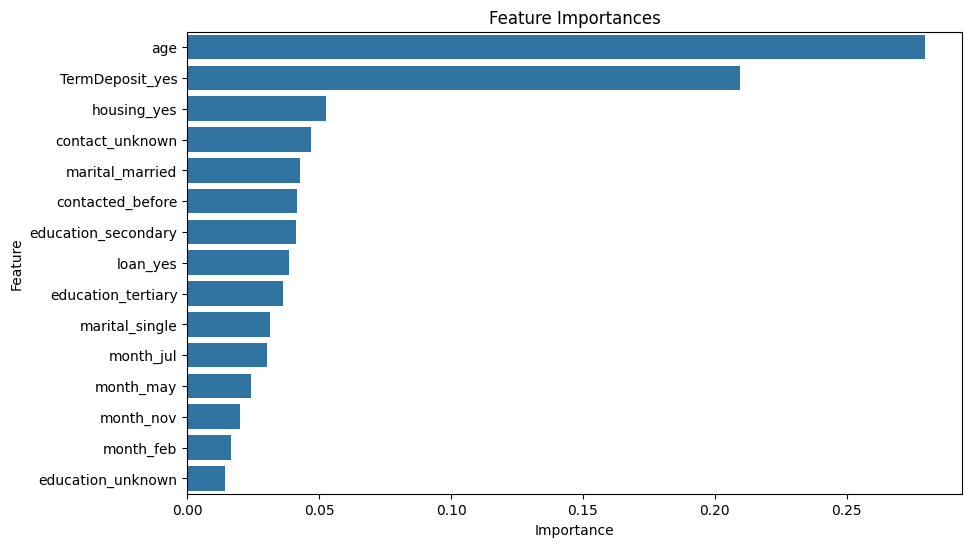

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Feature Importances")
plt.show()

---
## 12. Evaluation Questions

### Which regression model works best in your case?

Among the three models tested, Linear Regression delivered the strongest results. It achieved the lowest prediction errors, with an MAE of 149.38 seconds and an RMSE of 216.40 seconds. It also obtained the highest R² value (0.18), meaning it explained more variation in contact duration than the other models.

The Decision Tree Regressor performed poorly, producing larger errors and a negative R² score (-0.40). This suggests that the model did not generalize well to new observations and may have overfit the training data. The Random Forest Regressor achieved a positive R² score, but its performance remained below that of Linear Regression.

Based on all three evaluation metrics, Linear Regression was the best model for this dataset.

### How good are the predictions?

The results show that predicting contact duration is possible to some extent, but the models are not highly accurate. On average, the best-performing model was off by roughly 149 seconds when estimating call duration. After removing extreme outliers, the average error decreased to approximately 125 seconds, suggesting that unusually long calls have a substantial impact on prediction accuracy.

The R² value of 0.18 indicates that most of the variation in contact duration remains unexplained. This is not surprising, as the dataset mainly contains demographic and campaign-related information. The actual length of a phone conversation is likely influenced by many additional factors that are not recorded in the data.

For example, customer engagement, communication style, the complexity of questions asked during the call, and the sales representative's approach could all affect call duration. Since these variables are unavailable, the model can only capture a limited part of what drives conversation length.

Although the predictive accuracy is relatively modest, the model still provides useful information about general patterns in customer interactions.

### What are factors/features that significantly impact the predicted price, and do they make sense?

Age was the most influential predictor of contact duration. This may indicate that different age groups engage differently during conversations with the bank.

The second most important variable was whether the customer subscribed to a term deposit. Customers who subscribed may have required more discussion, clarification, or information before making a decision, which could naturally lead to longer calls.

Several other variables also contributed to the predictions, including housing loan status, contact type, marital status, and whether the customer had been contacted previously. These factors may reflect differences in customer circumstances, financial needs, or familiarity with the bank's marketing.

Education level and the month of contact also appeared among the more important variables. While their individual effects were smaller, they still provided useful information for explaining variation.

Overall, the most important predictors appear reasonable from a business perspective. Customer demographics, financial situation, and previous interactions with the bank are all factors that could influence how long a call lasts.

### What other/next steps would you recommend for building a regression model to predict the duration of a customer contact?

Several improvements could be recommended for future work.

One possibility is to optimize the Decision Tree and Random Forest models by testing different parameter combinations. This may improve their ability to generalize and reduce prediction errors.

Another improvement would be to use cross-validation rather than relying on a single train-test split. This would provide a more robust estimate of model performance and reduce the influence of a particular random split.

The target variable itself may also benefit from additional preprocessing. Since contact duration is heavily right-skewed and contains some extremely long calls, transforming the variable or handling outliers differently could improve model accuracy.